# MONAI DenseNet121 Version

This notebook was updated to use **MONAI DenseNet121** for federated learning experiments on the NIH ChestXray14 dataset.

## Included Experiments
- FedAvg
- FedProx
- FedAdam
- IID and poisoned federated settings
- PGD adversarial attack
- FGSM adversarial attack
- Label poisoning attack
- Grad-CAM explainability


# NIH Chest X-ray (NIH14) — Multi-label Federated Learning with Adversarial Clients (FGSM / PGD)

This notebook is **fully populated**. It implements:

- NIH14 **multi-label** classification (**14 diseases**, `"No Finding"` → all zeros)
- Optional **dominant-label balancing** (undersample + oversample) to equalize dominant class counts
- FL algorithms: **FedAvg**, **FedProx**, **FedNova**
- Splits: **IID** and **Dirichlet non-IID**
- Adversarial client(s): **FGSM** or **PGD** during **local training only** (validation stays clean)
- Metrics:
  - macro label-wise accuracy, recall, AUROC
  - **per-label AUROC tables**
  - per-label TP/FP/TN/FN on validation
  - per-client drift tables (clean vs adversarial)
- XAI:
  - Grad-CAM clean-global vs adversarial-global (dependency-free implementation)

> Expected CSV columns: `Image Index`, `Finding Labels`  
> Expected image folder: `DATA_ROOT` contains image files referenced by `Image Index`.

## 1) Setup & configuration

In [3]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

from monai.data import Dataset as MonaiDataset
from monai.transforms import (
    Compose, LoadImageD, EnsureChannelFirstD, ResizeD, ScaleIntensityD, EnsureTypeD,
    RandFlipD, RandRotate90D
)
from monai.networks.nets import densenet121

# =========================
# Paths (EDIT THESE)
# =========================
DATA_ROOT = "/home/niddal/Downloads/sample/sample/images"
CSV_PATH  = os.path.join(DATA_ROOT, "sample_labels.csv")  # columns: Image Index, Finding Labels

# =========================
# Reproducibility
# =========================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# Sanity mode (fast debug)
# =========================
SANITY_TEST = False
SANITY_N = 1500  # used if SANITY_TEST=True

# =========================
# Federated learning config
# =========================
NUM_CLIENTS       = 5
NUM_GLOBAL_ROUNDS = 3
LOCAL_EPOCHS      = 1
BATCH_SIZE        = 8
LR                = 1e-4
MU_FEDPROX        = 0.01

# =========================
# Non-IID split (Dirichlet)
# =========================
DIRICHLET_ALPHA = 0.3
NONIID_MIN_SIZE = 20

# =========================
# Adversarial client config
# =========================
MALICIOUS_CLIENTS = [0]      # list of client ids that attack
ATTACK_TYPE = "pgd"          # "fgsm" or "pgd"
EPSILON     = 0.06           # L_inf budget in [0,1] after ScaleIntensityD
PGD_ALPHA   = 0.01           # PGD step size
PGD_STEPS   = 7              # PGD iterations

# =========================
# Dominant-label balancing (optional)
# =========================
BALANCE_DATA = True
TARGET_PER_CLASS = 700  # dominant-class target count (undersample/oversample to this)

print("Attack:", ATTACK_TYPE, "eps=", EPSILON, "PGD(alpha,steps)=", (PGD_ALPHA, PGD_STEPS))
print("Balance dominant classes:", BALANCE_DATA, "TARGET_PER_CLASS:", TARGET_PER_CLASS)

Device: cpu
Attack: pgd eps= 0.06 PGD(alpha,steps)= (0.01, 7)
Balance dominant classes: True TARGET_PER_CLASS: 700


## 2) Load CSV + build NIH14 multi-hot labels

In [4]:
df = pd.read_csv(CSV_PATH)

# Parse label text list
df["Finding Labels"] = df["Finding Labels"].astype(str).apply(lambda x: x.split("|"))

# NIH14 diseases (standard set)
NIH_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
]
NUM_LABELS = len(NIH_LABELS)
label_to_idx = {l:i for i,l in enumerate(NIH_LABELS)}
idx_to_label = {i:l for l,i in label_to_idx.items()}

def make_multi_hot(lbl_list):
    v = np.zeros(NUM_LABELS, dtype=np.float32)
    for lab in lbl_list:
        if lab in label_to_idx:
            v[label_to_idx[lab]] = 1.0
    return v

df["multi_hot"] = df["Finding Labels"].apply(make_multi_hot)
df["image_path"] = df["Image Index"].apply(lambda p: os.path.join(DATA_ROOT, p))
df = df.reset_index(drop=True)

if SANITY_TEST:
    df = df.sample(n=min(SANITY_N, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"⚠ SANITY_TEST=True -> using {len(df)} samples")

Y = np.stack(df["multi_hot"].values)
print("Samples:", len(df), "Labels:", NUM_LABELS)
print("Any-disease samples:", int((Y.sum(axis=1)>0).sum()))
print("Avg positives/sample:", float(Y.sum(axis=1).mean()))

Samples: 5606 Labels: 14
Any-disease samples: 2562
Avg positives/sample: 0.7017481327056885


## 3) Prevalence diagnostics + dominant-label balancing (undersample + oversample)

=== Label prevalence (before balancing) ===


,label,positives,negatives,pos_rate
3,Infiltration,967,4639,0.172494
2,Effusion,644,4962,0.114877
0,Atelectasis,508,5098,0.090617
5,Nodule,313,5293,0.055833
4,Mass,284,5322,0.050660
7,Pneumothorax,271,5335,0.048341
8,Consolidation,226,5380,0.040314
12,Pleural_Thickening,176,5430,0.031395
1,Cardiomegaly,141,5465,0.025152
10,Emphysema,127,5479,0.022654


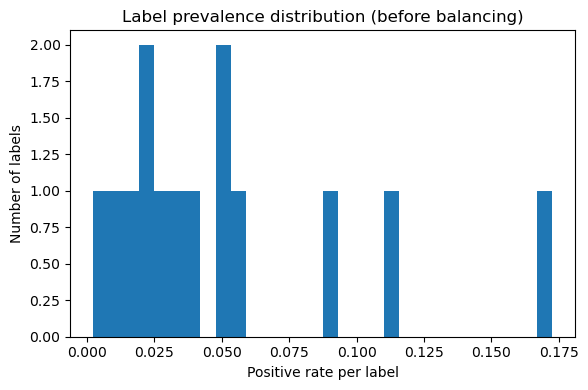

✅ Balanced df size: 9800
=== Dominant-label distribution AFTER balancing ===


,dominant_idx,count,dominant_label
0,0,700,Atelectasis
1,1,700,Cardiomegaly
2,2,700,Effusion
3,3,700,Infiltration
4,4,700,Mass
5,5,700,Nodule
6,6,700,Pneumonia
7,7,700,Pneumothorax
8,8,700,Consolidation
9,9,700,Edema


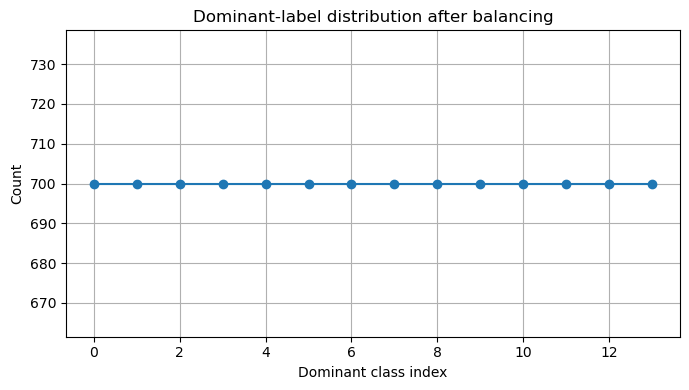

,label,positives_after
3,Infiltration,2012
2,Effusion,1733
4,Mass,1216
5,Nodule,1089
7,Pneumothorax,1070
8,Consolidation,1067
12,Pleural_Thickening,943
9,Edema,892
10,Emphysema,874
1,Cardiomegaly,868


In [5]:
# --- Prevalence table ---
Y = np.stack(df["multi_hot"].values)
pos_counts = Y.sum(axis=0).astype(int)
neg_counts = (Y.shape[0] - pos_counts).astype(int)

prev = pd.DataFrame({
    "label": NIH_LABELS,
    "positives": pos_counts,
    "negatives": neg_counts,
    "pos_rate": pos_counts / max(1, Y.shape[0]),
}).sort_values("positives", ascending=False)

print("=== Label prevalence (before balancing) ===")
display(prev)

plt.figure(figsize=(6,4))
plt.hist(prev["pos_rate"].values, bins=30)
plt.xlabel("Positive rate per label")
plt.ylabel("Number of labels")
plt.title("Label prevalence distribution (before balancing)")
plt.tight_layout()
plt.show()

# --- Dominant label (random among positives; deterministic via seed) ---
rng = np.random.default_rng(RANDOM_SEED)

def dominant_label(vec):
    v = np.asarray(vec)
    pos = np.where(v == 1)[0]
    if len(pos) > 0:
        return int(rng.choice(pos))
    # "No Finding" is represented as all zeros; for balancing we map it to bucket 0
    return 0

df["dominant"] = df["multi_hot"].apply(dominant_label)

# --- Balance by dominant label (approx multi-label balancing) ---
if BALANCE_DATA:
    grouped = []
    for c in range(NUM_LABELS):
        grp = df[df["dominant"] == c]
        if len(grp) == 0:
            continue
        if len(grp) > TARGET_PER_CLASS:
            grp2 = grp.sample(n=TARGET_PER_CLASS, replace=False, random_state=RANDOM_SEED)
        else:
            grp2 = grp.sample(n=TARGET_PER_CLASS, replace=True, random_state=RANDOM_SEED)
        grouped.append(grp2)

    df_balanced = pd.concat(grouped, axis=0).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    print("✅ Balanced df size:", len(df_balanced))
else:
    df_balanced = df.copy()
    print("⚠ BALANCE_DATA=False -> using original df size:", len(df_balanced))

# Verify dominant distribution
dom_counts = df_balanced["dominant"].value_counts().sort_index()
bal_table = pd.DataFrame({"dominant_idx": dom_counts.index, "count": dom_counts.values})
bal_table["dominant_label"] = bal_table["dominant_idx"].map(idx_to_label)
print("=== Dominant-label distribution AFTER balancing ===")
display(bal_table)

plt.figure(figsize=(7,4))
plt.plot(bal_table["count"].values, marker="o")
plt.xlabel("Dominant class index")
plt.ylabel("Count")
plt.title("Dominant-label distribution after balancing")
plt.grid(True)
plt.tight_layout()
plt.show()

# Verify per-label positives after balancing
Yb = np.stack(df_balanced["multi_hot"].values)
after_counts = Yb.sum(axis=0).astype(int)
post = pd.DataFrame({"label": NIH_LABELS, "positives_after": after_counts})
display(post.sort_values("positives_after", ascending=False))

## 4) Train/Val split + MONAI transforms (force grayscale + early channel guard)

In [6]:
train_df, val_df = train_test_split(
    df_balanced, test_size=0.2, random_state=RANDOM_SEED, shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))

train_items = [{"image": r["image_path"], "label": r["multi_hot"]} for _, r in train_df.iterrows()]
val_items   = [{"image": r["image_path"], "label": r["multi_hot"]} for _, r in val_df.iterrows()]

def force_gray(x):
    if isinstance(x, torch.Tensor):
        if x.ndim == 2:
            return x.unsqueeze(0)
        if x.ndim == 3:
            if x.shape[0] == 1:
                return x
            return x.float().mean(dim=0, keepdim=True)
    return x

def ForceGrayD(keys):
    def _fn(data):
        for k in keys:
            data[k] = force_gray(data[k])
        return data
    return _fn

def EnsureTensorLabelD(key="label"):
    def _fn(data):
        v = data[key]
        if isinstance(v, np.ndarray):
            data[key] = torch.from_numpy(v.astype(np.float32))
        elif isinstance(v, list):
            data[key] = torch.tensor(v, dtype=torch.float32)
        elif isinstance(v, torch.Tensor):
            data[key] = v.float()
        else:
            data[key] = torch.tensor(np.asarray(v, dtype=np.float32))
        return data
    return _fn

train_tfm = Compose([
    LoadImageD(keys=["image"]),
    EnsureChannelFirstD(keys=["image"]),
    ForceGrayD(keys=["image"]),
    ResizeD(keys=["image"], spatial_size=(224,224)),
    ScaleIntensityD(keys=["image"]),
    RandFlipD(keys=["image"], prob=0.5),
    RandRotate90D(keys=["image"], prob=0.5),
    EnsureTensorLabelD("label"),
    EnsureTypeD(keys=["image", "label"]),
])

val_tfm = Compose([
    LoadImageD(keys=["image"]),
    EnsureChannelFirstD(keys=["image"]),
    ForceGrayD(keys=["image"]),
    ResizeD(keys=["image"], spatial_size=(224,224)),
    ScaleIntensityD(keys=["image"]),
    EnsureTensorLabelD("label"),
    EnsureTypeD(keys=["image", "label"]),
])

train_ds = MonaiDataset(train_items, transform=train_tfm)
val_ds   = MonaiDataset(val_items,   transform=val_tfm)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Crash early if channels != 1 or label dims wrong
b = next(iter(val_loader))
print("Val batch shapes:", b["image"].shape, b["label"].shape)
assert b["image"].ndim == 4, f"Expected [B,C,H,W], got {b['image'].shape}"
assert b["image"].shape[1] == 1, f"Expected grayscale C=1, got C={b['image'].shape[1]}"
assert b["label"].shape[1] == NUM_LABELS, f"Expected label dim={NUM_LABELS}, got {b['label'].shape}"

Train: 7840 Val: 1960
Val batch shapes: torch.Size([8, 1, 224, 224]) torch.Size([8, 14])


## 5) IID + Dirichlet non-IID splits + client loaders

In [7]:
from typing import List

def iid_split(n, k):
    idxs = list(range(n))
    random.shuffle(idxs)
    return [idxs[i::k] for i in range(k)]

def dominant_bucket(multihot):
    v = np.asarray(multihot)
    pos = np.where(v == 1)[0]
    if len(pos) > 0:
        return int(pos[0])
    return NUM_LABELS  # no-finding bucket

def noniid_dirichlet_split(df_src, num_clients, alpha=0.3, min_size=20):
    labels = np.stack(df_src["multi_hot"].values)
    dom = np.array([dominant_bucket(v) for v in labels])
    K = NUM_LABELS + 1

    while True:
        clients = [[] for _ in range(num_clients)]
        for k in range(K):
            idx_k = np.where(dom == k)[0]
            if len(idx_k) == 0:
                continue
            np.random.shuffle(idx_k)
            p = np.random.dirichlet([alpha]*num_clients)
            sizes = (p*len(idx_k)).astype(int)
            while sizes.sum() < len(idx_k):
                sizes[np.random.randint(num_clients)] += 1
            while sizes.sum() > len(idx_k):
                j = int(np.argmax(sizes))
                if sizes[j] > 0:
                    sizes[j] -= 1
                else:
                    break
            start = 0
            for cid in range(num_clients):
                end = start + sizes[cid]
                clients[cid].extend(idx_k[start:end].tolist())
                start = end
        if min(len(c) for c in clients) >= min_size:
            for cid in range(num_clients):
                random.shuffle(clients[cid])
            return clients

def build_client_loaders(df_src, splits, transform, shuffle=True):
    loaders = []
    for idxs in splits:
        items = [{"image": df_src.iloc[i]["image_path"], "label": df_src.iloc[i]["multi_hot"]} for i in idxs]
        ds = MonaiDataset(items, transform=transform)
        loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0))
    return loaders

iid_splits    = iid_split(len(train_df), NUM_CLIENTS)
noniid_splits = noniid_dirichlet_split(train_df, NUM_CLIENTS, alpha=DIRICHLET_ALPHA, min_size=NONIID_MIN_SIZE)

print("IID sizes:", [len(s) for s in iid_splits])
print("nonIID sizes:", [len(s) for s in noniid_splits])

IID sizes: [1568, 1568, 1568, 1568, 1568]
nonIID sizes: [1412, 1211, 2591, 1762, 864]


## 6) Model, loss (pos_weight), evaluation metrics + per-label AUROC tables

In [6]:
def create_model():
    m = resnet18(spatial_dims=2, n_input_channels=1, num_classes=NUM_LABELS)
    return m.to(device)

def get_params(model):
    return {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

def set_params(model, params):
    model.load_state_dict({k: v.to(device) for k,v in params.items()}, strict=True)

Ytr = np.stack(train_df["multi_hot"].values)
pos = Ytr.sum(axis=0)
neg = len(Ytr) - pos
pos_weight = torch.tensor((neg / np.maximum(pos, 1.0)).astype(np.float32), device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print("pos_weight min/max:", float(pos_weight.min()), float(pos_weight.max()))

def multilabel_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.int32)

    TP = (y_true * y_pred).sum(axis=0)
    FP = ((1-y_true) * y_pred).sum(axis=0)
    TN = ((1-y_true) * (1-y_pred)).sum(axis=0)
    FN = (y_true * (1-y_pred)).sum(axis=0)

    acc_label = (TP + TN) / np.maximum(TP+TN+FP+FN, 1)
    rec_label = TP / np.maximum(TP+FN, 1)

    macro_acc = float(np.nanmean(acc_label))
    macro_rec = float(np.nanmean(rec_label))

    aurocs = {}
    auroc_vals = []
    for i in range(NUM_LABELS):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        if len(np.unique(yt)) < 2:
            aurocs[idx_to_label[i]] = np.nan
        else:
            a = float(roc_auc_score(yt, yp))
            aurocs[idx_to_label[i]] = a
            auroc_vals.append(a)
    macro_auroc = float(np.nanmean(auroc_vals)) if len(auroc_vals)>0 else float("nan")

    return {
        "macro_accuracy": macro_acc,
        "macro_recall": macro_rec,
        "macro_auroc": macro_auroc,
        "per_label_auroc": aurocs,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
    }

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device).float()
        logits = model(x)
        p = torch.sigmoid(logits)
        ys.append(y.cpu().numpy())
        ps.append(p.cpu().numpy())
    y_true = np.concatenate(ys, axis=0)
    y_prob = np.concatenate(ps, axis=0)
    m = multilabel_metrics(y_true, y_prob)
    m["y_true"] = y_true
    m["y_prob"] = y_prob
    return m

pos_weight min/max: 3.8908298015594482 13.35897445678711


In [19]:
from monai.networks.nets import DenseNet121
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score

# =========================================================

# MONAI DenseNet121 (Pretrained)

# =========================================================

def create_model():
    m = DenseNet121(spatial_dims=2, in_channels=1, out_channels=NUM_LABELS)
    return m.to(device)

def get_params(model):
    return {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

def set_params(model, params):
    model.load_state_dict({k: v.to(device) for k,v in params.items()}, strict=True)

Ytr = np.stack(train_df["multi_hot"].values)
pos = Ytr.sum(axis=0)
neg = len(Ytr) - pos
pos_weight = torch.tensor((neg / np.maximum(pos, 1.0)).astype(np.float32), device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print("pos_weight min/max:", float(pos_weight.min()), float(pos_weight.max()))

def multilabel_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.int32)

    TP = (y_true * y_pred).sum(axis=0)
    FP = ((1-y_true) * y_pred).sum(axis=0)
    TN = ((1-y_true) * (1-y_pred)).sum(axis=0)
    FN = (y_true * (1-y_pred)).sum(axis=0)

    acc_label = (TP + TN) / np.maximum(TP+TN+FP+FN, 1)
    rec_label = TP / np.maximum(TP+FN, 1)

    macro_acc = float(np.nanmean(acc_label))
    macro_rec = float(np.nanmean(rec_label))

    aurocs = {}
    auroc_vals = []
    for i in range(NUM_LABELS):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        if len(np.unique(yt)) < 2:
            aurocs[idx_to_label[i]] = np.nan
        else:
            a = float(roc_auc_score(yt, yp))
            aurocs[idx_to_label[i]] = a
            auroc_vals.append(a)
    macro_auroc = float(np.nanmean(auroc_vals)) if len(auroc_vals)>0 else float("nan")

    return {
        "macro_accuracy": macro_acc,
        "macro_recall": macro_rec,
        "macro_auroc": macro_auroc,
        "per_label_auroc": aurocs,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
    }

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device).float()
        logits = model(x)
        p = torch.sigmoid(logits)
        ys.append(y.cpu().numpy())
        ps.append(p.cpu().numpy())
    y_true = np.concatenate(ys, axis=0)
    y_prob = np.concatenate(ps, axis=0)
    m = multilabel_metrics(y_true, y_prob)
    m["y_true"] = y_true
    m["y_prob"] = y_prob
    return m

pos_weight min/max: 3.8908298015594482 13.35897445678711


## 7) Adversarial attacks (FGSM, PGD)

In [20]:
def fgsm_attack(model, x, y, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = criterion(logits, y)
    loss.backward()
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0.0, 1.0).detach()

def pgd_attack(model, x, y, epsilon, alpha, steps):
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = criterion(logits, y)
        loss.backward()
        x_adv = x_adv + alpha * x_adv.grad.sign()
        x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
        x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()
    return x_adv

def maybe_attack_batch(model, x, y, attack_type):
    if attack_type is None:
        return x
    if attack_type == "fgsm":
        return fgsm_attack(model, x, y, EPSILON)
    if attack_type == "pgd":
        return pgd_attack(model, x, y, EPSILON, PGD_ALPHA, PGD_STEPS)
    raise ValueError(f"Unknown ATTACK_TYPE={attack_type}")

## 8) Local training + aggregation (FedAvg/FedProx/FedNova)

In [21]:
def local_train_fedavg_or_fedprox(global_params, loader, fedprox=False, mu=0.01,
                                  adversarial=False, attack_type=None):
    model = create_model()
    set_params(model, global_params)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    global_dev = {k: v.to(device) for k,v in global_params.items()} if fedprox else None

    total = 0
    for _ in range(LOCAL_EPOCHS):
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["label"].to(device).float()

            if adversarial and attack_type is not None:
                x = maybe_attack_batch(model, x, y, attack_type)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)

            if fedprox:
                sd = model.state_dict()
                prox = 0.0
                for k in global_dev.keys():
                    if k in sd and sd[k].dtype.is_floating_point:
                        prox = prox + torch.sum((sd[k] - global_dev[k])**2)
                loss = loss + (mu/2.0)*prox

            loss.backward()
            opt.step()
            total += x.size(0)

    return get_params(model), total

def local_train_fednova(global_params, loader, adversarial=False, attack_type=None):
    model = create_model()
    set_params(model, global_params)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    tau = 0
    for _ in range(LOCAL_EPOCHS):
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["label"].to(device).float()

            if adversarial and attack_type is not None:
                x = maybe_attack_batch(model, x, y, attack_type)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()
            tau += 1

    new_params = get_params(model)
    delta = {k: global_params[k] - new_params[k] for k in global_params.keys()}
    return new_params, delta, max(1, tau)

def aggregate_fedavg(client_params_list, client_sizes):
    total = float(sum(client_sizes))
    out = {}
    for k in client_params_list[0].keys():
        out[k] = sum(cp[k] * (sz/total) for cp,sz in zip(client_params_list, client_sizes))
    return out

def aggregate_fednova(global_params, deltas_list, taus, client_sizes):
    total = float(sum(client_sizes))
    out = {k: v.clone() for k,v in global_params.items()}
    for k in out.keys():
        agg = 0.0
        for delta, tau, sz in zip(deltas_list, taus, client_sizes):
            agg = agg + (sz/total) * (delta[k] / tau)
        out[k] = out[k] - agg
    return out

## 9) Full FL training loop (clean vs adversarial) for IID & non-IID

In [22]:
def run_fl_experiment(algorithm, splits, adversarial=False):
    loaders = build_client_loaders(train_df, splits, train_tfm, shuffle=True)

    global_model  = create_model()
    global_params = get_params(global_model)

    metrics_over_rounds = {"macro_accuracy": [], "macro_recall": [], "macro_auroc": []}
    per_label_auroc_over_rounds = []

    for rnd in range(NUM_GLOBAL_ROUNDS):
        print(f"[{algorithm} | adversarial={adversarial} | round {rnd+1}/{NUM_GLOBAL_ROUNDS}]")

        client_params_list, client_sizes = [], []
        deltas_list, taus = [], []

        for cid, loader in enumerate(loaders):
            is_adv = adversarial and (cid in MALICIOUS_CLIENTS)
            atk = ATTACK_TYPE if is_adv else None

            if algorithm == "fedavg":
                p, n = local_train_fedavg_or_fedprox(global_params, loader, fedprox=False,
                                                     adversarial=is_adv, attack_type=atk)
                client_params_list.append(p); client_sizes.append(n)
            elif algorithm == "fedprox":
                p, n = local_train_fedavg_or_fedprox(global_params, loader, fedprox=True, mu=MU_FEDPROX,
                                                     adversarial=is_adv, attack_type=atk)
                client_params_list.append(p); client_sizes.append(n)
            elif algorithm == "fednova":
                p, d, t = local_train_fednova(global_params, loader, adversarial=is_adv, attack_type=atk)
                client_params_list.append(p); client_sizes.append(len(loader.dataset))
                deltas_list.append(d); taus.append(t)
            else:
                raise ValueError("Unknown algorithm")

        if algorithm in ["fedavg","fedprox"]:
            global_params = aggregate_fedavg(client_params_list, client_sizes)
        else:
            global_params = aggregate_fednova(global_params, deltas_list, taus, client_sizes)

        set_params(global_model, global_params)
        m = evaluate_model(global_model, val_loader)

        metrics_over_rounds["macro_accuracy"].append(m["macro_accuracy"])
        metrics_over_rounds["macro_recall"].append(m["macro_recall"])
        metrics_over_rounds["macro_auroc"].append(m["macro_auroc"])
        per_label_auroc_over_rounds.append(m["per_label_auroc"])

        print("  Val:", {k: float(m[k]) for k in ["macro_accuracy","macro_recall","macro_auroc"]})

    # Per-client eval using final global model
    per_client_rows = []
    for cid, loader in enumerate(loaders):
        mm = create_model(); set_params(mm, global_params)
        em = evaluate_model(mm, loader)
        per_client_rows.append({
            "client": cid,
            "macro_accuracy": em["macro_accuracy"],
            "macro_recall": em["macro_recall"],
            "macro_auroc": em["macro_auroc"],
            "adversarial_client": (cid in MALICIOUS_CLIENTS) if adversarial else False,
        })
    per_client_df = pd.DataFrame(per_client_rows)

    return {
        "final_params": global_params,
        "metrics_over_rounds": metrics_over_rounds,
        "per_label_auroc_over_rounds": per_label_auroc_over_rounds,
        "per_client_metrics": per_client_df,
    }

algorithms = ["fedavg","fedprox","fednova"]
results = {"IID": {"clean": {}, "adv": {}}, "nonIID": {"clean": {}, "adv": {}}}

for split_name, splits in [("IID", iid_splits), ("nonIID", noniid_splits)]:
    print("\n==========", split_name, "==========")
    for alg in algorithms:
        print(f"\n--- {split_name} | {alg} | CLEAN ---")
        results[split_name]["clean"][alg] = run_fl_experiment(alg, splits, adversarial=False)

        print(f"\n--- {split_name} | {alg} | ADV ({ATTACK_TYPE}, eps={EPSILON}) ---")
        results[split_name]["adv"][alg] = run_fl_experiment(alg, splits, adversarial=True)


========== IID ==========

--- IID | fedavg | CLEAN ---
[fedavg | adversarial=False | round 1/3]
  Val: {'macro_accuracy': 0.5071793002915451, 'macro_recall': 0.7010916166589214, 'macro_auroc': 0.6487941797919584}
[fedavg | adversarial=False | round 2/3]
  Val: {'macro_accuracy': 0.5989431486880468, 'macro_recall': 0.6463181292826282, 'macro_auroc': 0.6825547443229211}
[fedavg | adversarial=False | round 3/3]
  Val: {'macro_accuracy': 0.6224125364431486, 'macro_recall': 0.6815496987302682, 'macro_auroc': 0.7100825078214015}

--- IID | fedavg | ADV (pgd, eps=0.06) ---
[fedavg | adversarial=True | round 1/3]
  Val: {'macro_accuracy': 0.49150874635568526, 'macro_recall': 0.6245169888146401, 'macro_auroc': 0.6404346048719363}
[fedavg | adversarial=True | round 2/3]
  Val: {'macro_accuracy': 0.5333819241982508, 'macro_recall': 0.5519295430675257, 'macro_auroc': 0.6564041628711712}
[fedavg | adversarial=True | round 3/3]
  Val: {'macro_accuracy': 0.5504737609329446, 'macro_recall': 0.592930

## 10) Summary tables + per-label AUROC tables

In [23]:
def final_per_label_auroc_table(split_name="IID", alg="fedavg", run="clean"):
    last = results[split_name][run][alg]["per_label_auroc_over_rounds"][-1]
    t = pd.DataFrame({"label": list(last.keys()), "AUROC": list(last.values())}).sort_values("AUROC", ascending=False)
    return t

display(final_per_label_auroc_table("IID","fedavg","clean").head(14))
display(final_per_label_auroc_table("IID","fedavg","adv").head(14))

def summary_table():
    rows = []
    for split_name in ["IID","nonIID"]:
        for run_key in ["clean","adv"]:
            for alg in algorithms:
                m = results[split_name][run_key][alg]["metrics_over_rounds"]
                rows.append({
                    "split": split_name,
                    "run": run_key,
                    "attack": ATTACK_TYPE if run_key=="adv" else "none",
                    "algorithm": alg,
                    "final_macro_acc": m["macro_accuracy"][-1],
                    "final_macro_recall": m["macro_recall"][-1],
                    "final_macro_auroc": m["macro_auroc"][-1],
                })
    return pd.DataFrame(rows)

display(summary_table().sort_values(["split","algorithm","run"]))

,label,AUROC
13,Hernia,0.992597
9,Edema,0.853903
6,Pneumonia,0.801480
11,Fibrosis,0.789208
8,Consolidation,0.728801
0,Atelectasis,0.683082
5,Nodule,0.664585
1,Cardiomegaly,0.661291
10,Emphysema,0.658943
12,Pleural_Thickening,0.643471


,label,AUROC
13,Hernia,0.919590
9,Edema,0.830566
6,Pneumonia,0.715069
11,Fibrosis,0.708074
8,Consolidation,0.702602
0,Atelectasis,0.653390
10,Emphysema,0.626978
12,Pleural_Thickening,0.623252
7,Pneumothorax,0.619871
1,Cardiomegaly,0.613747


,split,run,attack,algorithm,final_macro_acc,final_macro_recall,final_macro_auroc
3,IID,adv,pgd,fedavg,0.550474,0.592930,0.669749
0,IID,clean,none,fedavg,0.622413,0.681550,0.710083
5,IID,adv,pgd,fednova,0.563010,0.428571,0.477448
2,IID,clean,none,fednova,0.321101,0.714286,0.504763
4,IID,adv,pgd,fedprox,0.575620,0.577604,0.669206
1,IID,clean,none,fedprox,0.589249,0.741329,0.708333
9,nonIID,adv,pgd,fedavg,0.787391,0.313213,0.679628
6,nonIID,clean,none,fedavg,0.736334,0.524596,0.709903
11,nonIID,adv,pgd,fednova,0.547157,0.432407,0.509456
8,nonIID,clean,none,fednova,0.689359,0.255864,0.487537


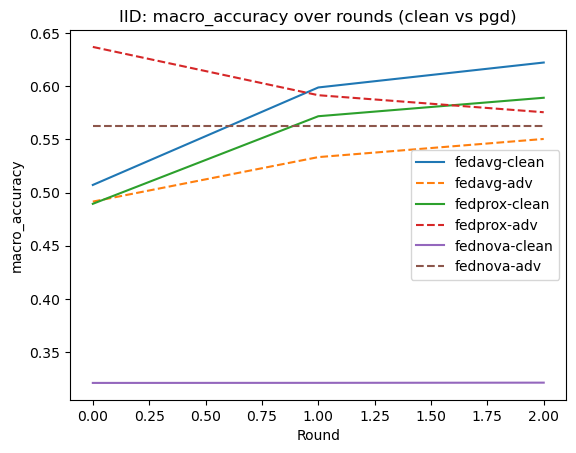

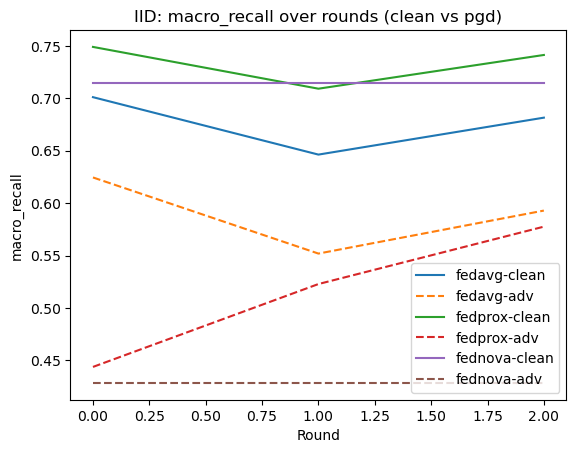

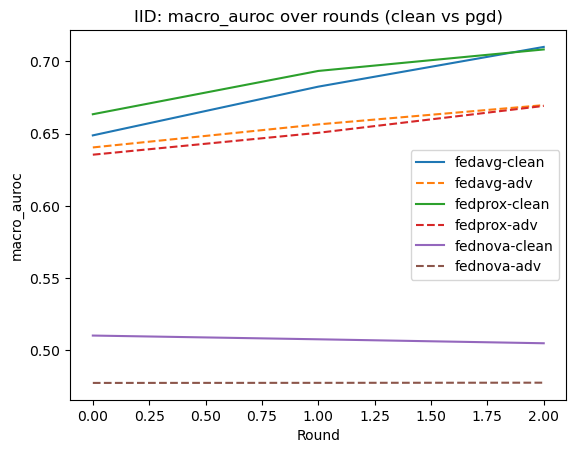

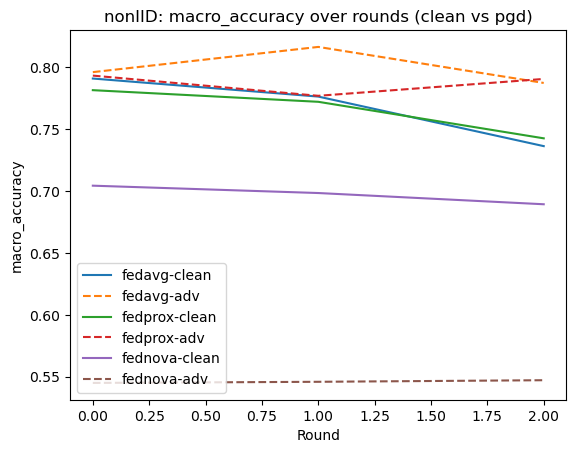

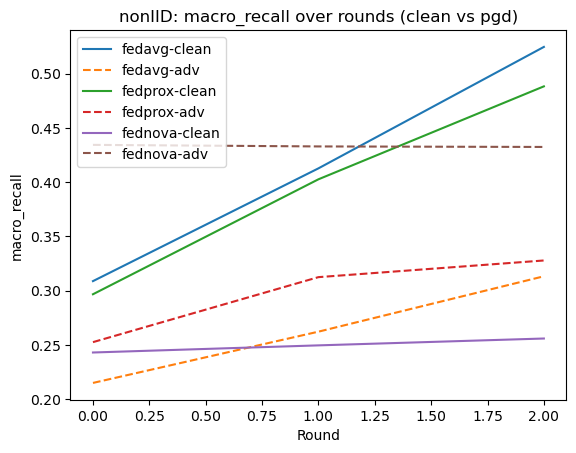

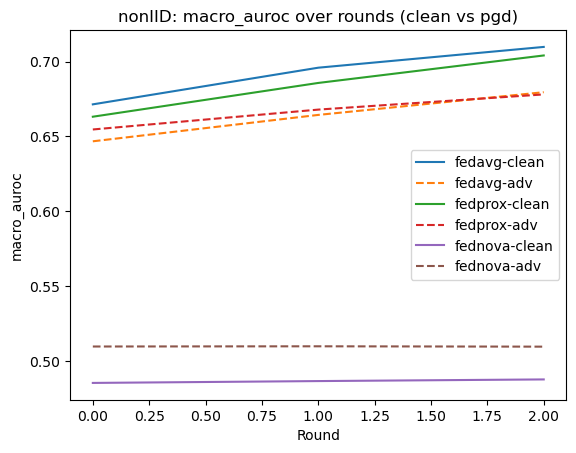

,client,macro_accuracy_clean,macro_recall_clean,macro_auroc_clean,adversarial_client_clean,macro_accuracy_adv,macro_recall_adv,macro_auroc_adv,adversarial_client_adv,delta_macro_accuracy,delta_macro_recall,delta_macro_auroc
0,0,0.621173,0.691946,0.714492,False,0.548196,0.583283,0.669519,True,-0.072977,-0.108663,-0.044974
1,1,0.615798,0.664948,0.697123,False,0.546556,0.583866,0.657928,False,-0.069242,-0.081083,-0.039195
2,2,0.616117,0.677155,0.703949,False,0.551066,0.597659,0.660165,False,-0.065051,-0.079495,-0.043783
3,3,0.622631,0.692314,0.714260,False,0.557170,0.602465,0.676010,False,-0.065461,-0.089849,-0.038250
4,4,0.618486,0.691837,0.707383,False,0.553389,0.603213,0.675017,False,-0.065097,-0.088625,-0.032366


In [24]:
def plot_metric(split_name, metric):
    plt.figure()
    for alg in algorithms:
        plt.plot(results[split_name]["clean"][alg]["metrics_over_rounds"][metric], label=f"{alg}-clean")
        plt.plot(results[split_name]["adv"][alg]["metrics_over_rounds"][metric], linestyle="--", label=f"{alg}-adv")
    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.title(f"{split_name}: {metric} over rounds (clean vs {ATTACK_TYPE})")
    plt.legend()
    plt.show()

for split_name in ["IID","nonIID"]:
    for metric in ["macro_accuracy","macro_recall","macro_auroc"]:
        plot_metric(split_name, metric)

def per_client_drift_table(split_name, alg):
    c = results[split_name]["clean"][alg]["per_client_metrics"].copy()
    a = results[split_name]["adv"][alg]["per_client_metrics"].copy()
    m = c.merge(a, on="client", suffixes=("_clean","_adv"))
    for metric in ["macro_accuracy","macro_recall","macro_auroc"]:
        m[f"delta_{metric}"] = m[f"{metric}_adv"] - m[f"{metric}_clean"]
    return m

display(per_client_drift_table("IID","fedavg"))

In [25]:
def final_per_label_auroc_table(split_name="IID", alg="fedavg", run="clean"):
    last = results[split_name][run][alg]["per_label_auroc_over_rounds"][-1]
    t = pd.DataFrame({"label": list(last.keys()), "AUROC": list(last.values())}).sort_values("AUROC", ascending=False)
    return t

display(final_per_label_auroc_table("IID","fedavg","clean").head(14))
display(final_per_label_auroc_table("IID","fedavg","adv").head(14))

,label,AUROC
13,Hernia,0.992597
9,Edema,0.853903
6,Pneumonia,0.801480
11,Fibrosis,0.789208
8,Consolidation,0.728801
0,Atelectasis,0.683082
5,Nodule,0.664585
1,Cardiomegaly,0.661291
10,Emphysema,0.658943
12,Pleural_Thickening,0.643471


,label,AUROC
13,Hernia,0.919590
9,Edema,0.830566
6,Pneumonia,0.715069
11,Fibrosis,0.708074
8,Consolidation,0.702602
0,Atelectasis,0.653390
10,Emphysema,0.626978
12,Pleural_Thickening,0.623252
7,Pneumothorax,0.619871
1,Cardiomegaly,0.613747


In [26]:
def confusion_table_for_label(m, label_name):
    i = label_to_idx[label_name]
    return pd.DataFrame([{
        "label": label_name,
        "TP": int(m["TP"][i]),
        "FP": int(m["FP"][i]),
        "TN": int(m["TN"][i]),
        "FN": int(m["FN"][i]),
        "recall": float(m["TP"][i] / max(1.0, (m["TP"][i] + m["FN"][i]))),
    }])

def eval_global(split_name, alg, run):
    p = results[split_name][run][alg]["final_params"]
    m = create_model(); set_params(m, p)
    return evaluate_model(m, val_loader)

m_clean = eval_global("IID","fedavg","clean")
m_adv   = eval_global("IID","fedavg","adv")

rows = []
for lab in NIH_LABELS:
    t1 = confusion_table_for_label(m_clean, lab).rename(columns={"TP":"TP_clean","FP":"FP_clean","TN":"TN_clean","FN":"FN_clean","recall":"recall_clean"})
    t2 = confusion_table_for_label(m_adv, lab).rename(columns={"TP":"TP_adv","FP":"FP_adv","TN":"TN_adv","FN":"FN_adv","recall":"recall_adv"})
    rows.append(t1.merge(t2, on="label"))
conf_df = pd.concat(rows, ignore_index=True)
display(conf_df.sort_values("recall_adv").head(10))

,label,TP_clean,FP_clean,TN_clean,FN_clean,recall_clean,TP_adv,FP_adv,TN_adv,FN_adv,recall_adv
5,Nodule,85,430,1337,108,0.440415,13,42,1725,180,0.067358
11,Fibrosis,98,377,1430,55,0.640523,19,128,1679,134,0.124183
6,Pneumonia,90,431,1391,48,0.652174,40,185,1637,98,0.289855
3,Infiltration,235,685,866,174,0.574572,121,354,1197,288,0.295844
12,Pleural_Thickening,89,482,1271,118,0.429952,79,402,1351,128,0.381643
2,Effusion,256,945,672,87,0.746356,170,557,1060,173,0.495627
9,Edema,157,602,1186,15,0.912791,94,275,1513,78,0.546512
8,Consolidation,145,801,959,55,0.725000,131,598,1162,69,0.655000
1,Cardiomegaly,121,1061,750,28,0.812081,112,1171,640,37,0.751678
0,Atelectasis,122,910,882,46,0.726190,138,1366,426,30,0.821429


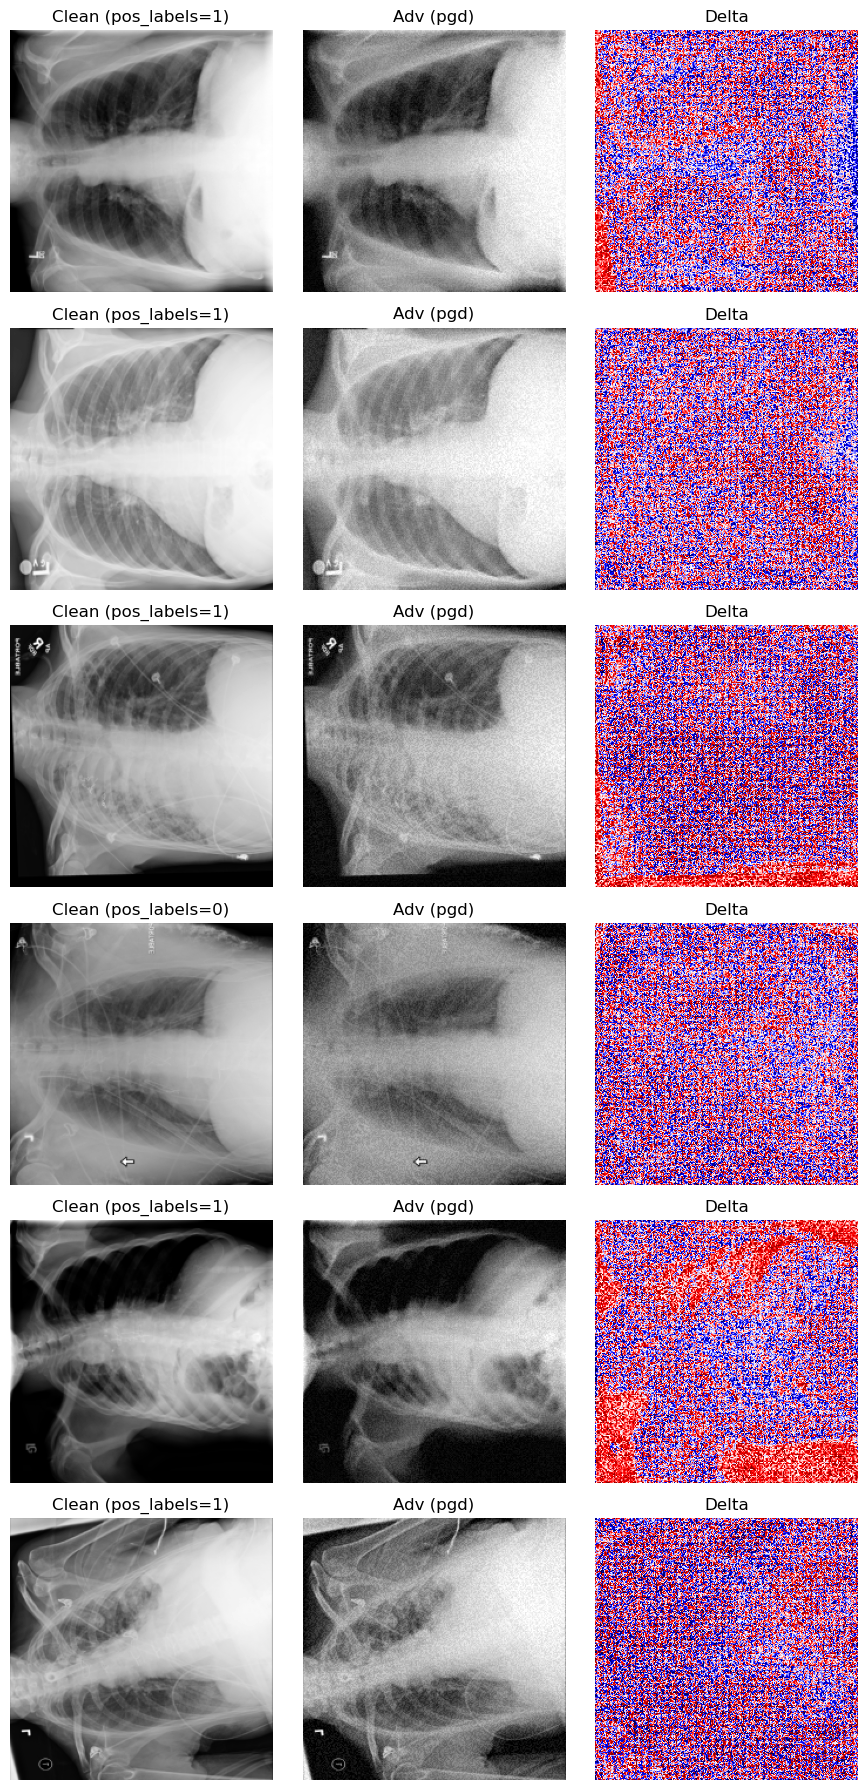

In [27]:
def visualize_adv_examples(split_name="IID", alg="fedavg", client_id=0, n_show=6):
    splits = iid_splits if split_name=="IID" else noniid_splits
    loaders = build_client_loaders(train_df, splits, val_tfm, shuffle=False)
    loader = loaders[client_id]

    params_adv = results[split_name]["adv"][alg]["final_params"]
    model = create_model(); set_params(model, params_adv)
    model.eval()

    batch = next(iter(loader))
    x = batch["image"].to(device)[:n_show]
    y = batch["label"].to(device).float()[:n_show]

    x_adv = maybe_attack_batch(model, x, y, ATTACK_TYPE)

    fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(n_show):
        img  = x[i,0].detach().cpu().numpy()
        adv  = x_adv[i,0].detach().cpu().numpy()
        diff = adv - img
        kpos = int(y[i].sum().item())

        axes[i,0].imshow(img, cmap="gray");     axes[i,0].set_title(f"Clean (pos_labels={kpos})"); axes[i,0].axis("off")
        axes[i,1].imshow(adv, cmap="gray");     axes[i,1].set_title(f"Adv ({ATTACK_TYPE})");       axes[i,1].axis("off")
        axes[i,2].imshow(diff, cmap="seismic"); axes[i,2].set_title("Delta");                      axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

# Example:
visualize_adv_examples("IID", "fedavg", client_id=MALICIOUS_CLIENTS[0], n_show=6)